<a href="https://colab.research.google.com/github/e23106-eng/Statistical-Learning-e23106/blob/main/Assignment_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**ASSIGNMENT 7 - KALMAN FILTER**

# Q. Analytical Derivation

Consider the filter model
\begin{align*}
x^{-}_k &= A_{k-1}\,x^{+}_{k-1} + G_{k-1}\,w_{k-1}, \\
y^{-}_k &= H_k\,x^{-}_k + z_k,
\end{align*}
where
$$x^{+}_{k-1} \sim \mathscr{N}(m_{k-1}, P_{k-1}),$$

Answer the followings:

1. Show that
$$x_k^- \sim \mathscr{N}(m_k^-, P_k^-),$$
where
$$m_k^- = A_{k-1}m_{k-1},$$
and
$$
P_k^- = A_{k-1}P_{k-1}A_{k-1}^T + G_{k-1}\Sigma_p G_{k-1}^T.
$$

2. Show that
$$y_k^- \sim \mathscr{N}(H_k m_k^-, H_k P_k^- H_k^T + \Sigma_m).$$

3. Show that
$$\begin{bmatrix} x_k^- \\ y^{-}_k \end{bmatrix} \sim \mathscr{N}\left(
\begin{bmatrix} m_k^- \\ H_k m_k^- \end{bmatrix},
\begin{bmatrix} P_k^- & P_k^- H_k^T \\ H_k P_k^- & H_k P_k^- H_k^T + \Sigma_m \end{bmatrix}
\right).$$

4. Show that
$$x^{+}_k\triangleq (x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}) \sim \mathscr{N}(m_k, P_k),$$
where the updated mean $m_k$ and updated covariance $P_k$ are given by:
\begin{align*}
K_k &\triangleq P_k^- H_k^T (H_k P_k^- H_k^T + \Sigma_m)^{-1}, \\
m_k &= m_k^- + K_k (y^{\mathrm{obs}}_{k} - H_k m_k^-), \\
P_k &= (I - K_k H_k) P_k^-.
\end{align*}

5. Find
$\mathbb{E}[x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}]$  and
$\text{Var}(x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k})$.

####**ANSWER**

**1.** Proof for $x_k^- \sim \mathcal{N}(m_k^-, P_k^-)$

Given the state transition equation:$$x_k^- = A_{k-1}x_{k-1}^+ + G_{k-1}w_{k-1}$$


where $x_{k-1}^+ \sim \mathcal{N}(m_{k-1}, P_{k-1})$ and $w_{k-1} \sim \mathcal{N}(0, \Sigma_p)$ are independent Gaussian random variables. Since any linear combination of Gaussian vectors remains Gaussian, $x_k^-$ is Gaussian.

Mean ($m_k^-$):$$m_k^- = \mathbb{E}[x_k^-] = \mathbb{E}[A_{k-1}x_{k-1}^+ + G_{k-1}w_{k-1}] = A_{k-1}\mathbb{E}[x_{k-1}^+] + G_{k-1}\mathbb{E}[w_{k-1}]$$

$$m_k^- = A_{k-1}m_{k-1} + G_{k-1}(0) = A_{k-1}m_{k-1}$$

Covariance ($P_k^-$):$$P_k^- = \text{Var}(A_{k-1}x_{k-1}^+ + G_{k-1}w_{k-1})$$

Since $x_{k-1}^+$ and $w_{k-1}$ are independent, their cross-covariance is zero:$$P_k^- = A_{k-1}\text{Var}(x_{k-1}^+)A_{k-1}^T + G_{k-1}\text{Var}(w_{k-1})G_{k-1}^T$$

$$P_k^- = A_{k-1}P_{k-1}A_{k-1}^T + G_{k-1}\Sigma_p G_{k-1}^T$$



**2.** Proof for $y_k^- \sim \mathcal{N}(H_k m_k^-, H_k P_k^- H_k^T + \Sigma_m)$

The measurement equation is given by $y_k^- = H_k x_k^- + z_k$, where $z_k \sim \mathcal{N}(0, \Sigma_m)$ is independent of $x_k^-$.

Mean:$$\mathbb{E}[y_k^-] = \mathbb{E}[H_k x_k^- + z_k] = H_k \mathbb{E}[x_k^-] + \mathbb{E}[z_k] = H_k m_k^-$$

Covariance:$$\text{Var}(y_k^-) = \text{Var}(H_k x_k^- + z_k) = H_k \text{Var}(x_k^-)H_k^T + \text{Var}(z_k) = H_k P_k^- H_k^T + \Sigma_m$$




**3.** Joint Distribution of $\begin{bmatrix} x_k^- \\ y_k^- \end{bmatrix}$

The joint distribution of two linear combinations of Gaussian vectors is jointly Gaussian. We already have the individual means and auto-covariances. We only need the cross-covariance $\text{Cov}(x_k^-, y_k^-)$:

$$\text{Cov}(x_k^-, y_k^-) = \mathbb{E}[(x_k^- - m_k^-)(y_k^- - H_k m_k^-)^T]$$
$$\text{Cov}(x_k^-, y_k^-) = \mathbb{E}[(x_k^- - m_k^-)(H_k(x_k^- - m_k^-) + z_k)^T]$$
$$\text{Cov}(x_k^-, y_k^-) = \mathbb{E}[(x_k^- - m_k^-)(x_k^- - m_k^-)^T]H_k^T + \mathbb{E}[(x_k^- - m_k^-)z_k^T]$$

Since $x_k^-$ and $z_k$ are independent, the second term vanishes:$$\text{Cov}(x_k^-, y_k^-) = P_k^- H_k^T$$

By symmetry, $\text{Cov}(y_k^-, x_k^-) = H_k P_k^-$. Therefore:

$$\begin{bmatrix} x_k^- \\ y_k^- \end{bmatrix} \sim \mathcal{N}\left( \begin{bmatrix} m_k^- \\ H_k m_k^- \end{bmatrix}, \begin{bmatrix} P_k^- & P_k^- H_k^T \\ H_k P_k^- & H_k P_k^- H_k^T + \Sigma_m \end{bmatrix} \right)$$




**4.** Proof for $x_k^+ \triangleq (x_k^- \mid y_k^- = y_k^{\text{obs}}) \sim \mathcal{N}(m_k, P_k)$

Using the standard Gaussian Conditioning Theorem, if $\begin{bmatrix} X \\ Y \end{bmatrix} \sim \mathcal{N}\left( \begin{bmatrix} \mu_X \\ \mu_Y \end{bmatrix}, \begin{bmatrix} \Sigma_{XX} & \Sigma_{XY} \\ \Sigma_{YX} & \Sigma_{YY} \end{bmatrix} \right)$, then the conditional distribution $X|Y=y$ is $\mathcal{N}(\mu_{X|Y}, \Sigma_{X|Y})$ where:

$$\mu_{X|Y} = \mu_X + \Sigma_{XY}\Sigma_{YY}^{-1}(y - \mu_Y)$$

$$\Sigma_{X|Y} = \Sigma_{XX} - \Sigma_{XY}\Sigma_{YY}^{-1}\Sigma_{YX}$$

Substituting our joint matrix elements:
$\mu_X = m_k^-$, $\mu_Y = H_k m_k^-$

$\Sigma_{XX} = P_k^-$, $\Sigma_{XY} = P_k^- H_k^T$, $\Sigma_{YY} = H_k P_k^- H_k^T + \Sigma_m$

Let the Kalman Gain be defined as:$$K_k \triangleq P_k^- H_k^T (H_k P_k^- H_k^T + \Sigma_m)^{-1}$$

**5.** Then:$$\mathbb{E}[x_k^- \mid y_k^- = y_k^{\text{obs}}] = m_k = m_k^- + K_k(y_k^{\text{obs}} - H_k m_k^-)$$

$$\text{Var}(x_k^- \mid y_k^- = y_k^{\text{obs}}) = P_k = P_k^- - K_k H_k P_k^- = (I - K_k H_k)P_k^-$$

# Q. 1-D Example

Consider the scalar linear-Gaussian filter model
\begin{aligned}
x^-_k &= a\,x^+_{k-1} + w_{k-1},\qquad w_{k-1}\sim\mathscr N(0,q),\\
y^-_k &= h\,x^-_k + z_k,\qquad\;\;\;\; z_k\sim\mathscr N(0,r),
\end{aligned}
with prior $x_0\sim \mathscr{N}(m_0,P_0)$. Define $Y_{k}=\{y^{\mathrm{obs}}_1,\dots,y^{\mathrm{obs}}_{k}\}$.

Answer the following:

1. Show that
\begin{aligned}
m_k^- &= a\,m_{k-1},\\
P_k^- &= a^2 P_{k-1} + q.
\end{aligned}

2. Show that
\begin{aligned}
m_k &= m_k^- + K_k\,v_k
= m_k^- + \frac{P_k^- h}{S_k}\bigl(y^{\mathrm{obs}}_k - h\,m_k^-\bigr),\\
P_k &= (1 - K_k h)\,P_k^-
= \Bigl(1 - \frac{P_k^- h^2}{S_k}\Bigr) P_k^- .
\end{aligned}

3. Show that the predictive measurement distribution (before seeing $y_k$):
\begin{align*}
p(y^-_k | Y_{k-1})=\mathscr N\bigl(h\,m_k^-,\; h^2 P_k^- + r\bigr).
\end{align*}

4. Show that the posterior-predictive measurement distribution (after filtering on $y_k$):
\begin{align*}
p(y^-_k\mid Y_k)=\mathscr N\bigl(h\,m_k,\; h^2 P_k + r\bigr).
\end{align*}

5. For suitable numerical values for $a,q,h,r$ animate the above to prior distribution and the posterior distribution.

####**ANSWER**

**1. Derivation of Predicted Mean ($m_k^-$) and Covariance ($P_k^-$**

Given the state dynamics equation:$$x^-_k = a\,x^+_{k-1} + w_{k-1}$$

where $x^+_{k-1} \mid Y_{k-1} \sim \mathscr{N}(m_{k-1}, P_{k-1})$ and $w_{k-1} \sim \mathscr{N}(0, q)$ are independent.

Predicted Mean ($m_k^-$):
Taking the conditional expectation with respect to $Y_{k-1}$:

$$m_k^- = \mathbb{E}[x^-_k \mid Y_{k-1}] = \mathbb{E}[a\,x^+_{k-1} + w_{k-1} \mid Y_{k-1}]$$

By linearity of expectation and the independence of the process noise:

$$m_k^- = a\,\mathbb{E}[x^+_{k-1} \mid Y_{k-1}] + \mathbb{E}[w_{k-1}] = a\,m_{k-1} + 0 = a\,m_{k-1}$$

Predicted Covariance ($P_k^-$):
Taking the conditional variance with respect to $Y_{k-1}$:
$$P_k^- = \text{Var}(x^-_k \mid Y_{k-1}) = \text{Var}(a\,x^+_{k-1} + w_{k-1} \mid Y_{k-1})$$

Since $x^+_{k-1}$ and $w_{k-1}$ are independent, their variances add up, and scaling constants come out squared:$$P_k^- = a^2 \text{Var}(x^+_{k-1} \mid Y_{k-1}) + \text{Var}(w_{k-1}) = a^2 P_{k-1} + q$$

**2. Derivation of Updated Mean ($m_k$) and Covariance ($P_k$)**

From the standard matrix Kalman filter equations, the innovation covariance is $S_k = H_k P_k^- H_k^T + R_k$, and the Kalman gain is $K_k = P_k^- H_k^T S_k^{-1}$. In a 1-D scalar environment, $H_k = h$ and $R_k = r$.

$$S_k = h^2 P_k^- + r$$

$$K_k = \frac{P_k^- h}{S_k}$$

Updated Mean ($m_k$):Using the scalar version of the state update equation with the innovation $v_k = y^{\mathrm{obs}}_k - h\,m_k^-$:

$$m_k = m_k^- + K_k\,v_k = m_k^- + \frac{P_k^- h}{S_k}\bigl(y^{\mathrm{obs}}_k - h\,m_k^-\bigr)$$

Updated Covariance ($P_k$):Using the Josephson update reduction form for the scalar field:
$$P_k = (1 - K_k h)\,P_k^- = \Bigl(1 - \frac{P_k^- h^2}{S_k}\Bigr) P_k^-$$

**3. Predictive Measurement Distribution $p(y^-_k \mid Y_{k-1})$**

Before observing the actual value $y^{\mathrm{obs}}_k$, the tracking profile relies entirely on the predicted state $x^-_k \mid Y_{k-1} \sim \mathscr{N}(m_k^-, P_k^-)$.

The observation equation defines $y^-_k = h\,x^-_k + z_k$.

Mean: $\mathbb{E}[y^-_k \mid Y_{k-1}] = h\,\mathbb{E}[x^-_k \mid Y_{k-1}] + \mathbb{E}[z_k] = h\,m_k^-$

Variance: $\text{Var}(y^-_k \mid Y_{k-1}) = h^2 \text{Var}(x^-_k \mid Y_{k-1}) + \text{Var}(z_k) = h^2 P_k^- + r$

Because $y^-_k$ is a linear combination of Gaussian variables, it is normal:

$$p(y^-_k \mid Y_{k-1}) = \mathscr{N}\bigl(h\,m_k^-,\; h^2 P_k^- + r\bigr)$$

**4. Posterior-Predictive Measurement Distribution $p(y^-_k \mid Y_k)$**

After filtering on the current measurement $y^{\mathrm{obs}}_k$, the updated state representation becomes $x^+_k \mid Y_k \sim \mathscr{N}(m_k, P_k)$.
Evaluating the next potential hypothetical measurement distribution matching the updated profile:

Mean: $\mathbb{E}[y^-_k \mid Y_k] = h\,\mathbb{E}[x^+_k \mid Y_k] + \mathbb{E}[z_k] = h\,m_k$

Variance: $\text{Var}(y^-_k \mid Y_k) = h^2 \text{Var}(x^+_k \mid Y_k) + \text{Var}(z_k) = h^2 P_k + r$

Thus, the posterior-predictive distribution is:
$$p(y^-_k \mid Y_k) = \mathscr{N}\bigl(h\,m_k,\; h^2 P_k + r\bigr)$$

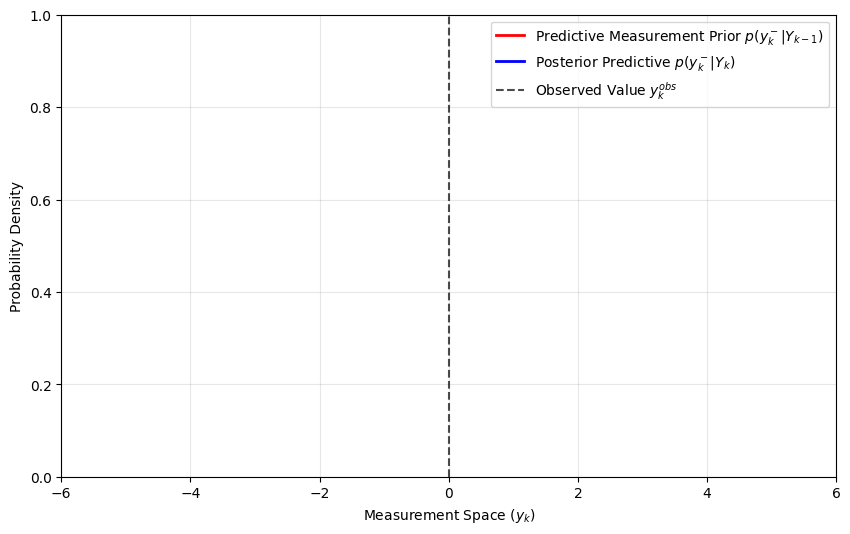

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy.stats import norm

# 1. System Parameters
np.random.seed(42)
a = 0.95    # State transition parameter
q = 0.4     # Process noise variance
h = 1.2     # Measurement sensitivity scaling
r = 0.6     # Measurement noise variance
N = 30      # Total time steps

# Prior Initial Parameters
m0 = 0.0
P0 = 2.0

# 2. Simulate Ground Truth and Measurements
x_true = np.zeros(N)
y_obs = np.zeros(N)

x_current = np.random.normal(m0, np.sqrt(P0))
for k in range(N):
    w = np.random.normal(0, np.sqrt(q))
    x_true[k] = a * (x_current if k > 0 else m0) + w
    z = np.random.normal(0, np.sqrt(r))
    y_obs[k] = h * x_true[k] + z
    x_current = x_true[k]

# 3. Precompute Kalman Filter Tracking Stages
m_hist, P_hist = [m0], [P0]
m_minus_hist, P_minus_hist = [], []

m, P = m0, P0
for k in range(N):
    # Prediction (Prior) Stage
    m_minus = a * m
    P_minus = a**2 * P + q
    m_minus_hist.append(m_minus)
    P_minus_hist.append(P_minus)

    # Update (Posterior) Stage
    S = h**2 * P_minus + r
    K = (P_minus * h) / S
    m = m_minus + K * (y_obs[k] - h * m_minus)
    P = (1 - K * h) * P_minus
    m_hist.append(m)
    P_hist.append(P)

# 4. Set up the Animation Canvas
fig, ax = plt.subplots(figsize=(10, 6))
x_axis = np.linspace(-6, 6, 500)

line_prior, = ax.plot([], [], 'r-', label='Predictive Measurement Prior $p(y^-_k|Y_{k-1})$', linewidth=2)
line_posterior, = ax.plot([], [], 'b-', label='Posterior Predictive $p(y^-_k|Y_k)$', linewidth=2)
meas_dot = ax.axvline(0, color='black', linestyle='--', alpha=0.7, label='Observed Value $y^{obs}_k$')
title_text = ax.text(0.05, 0.95, '', transform=ax.transAxes, fontsize=12, fontweight='bold', va='top')

def init():
    ax.set_xlim(-6, 6)
    ax.set_ylim(0, 1.0)
    ax.set_xlabel('Measurement Space ($y_k$)')
    ax.set_ylabel('Probability Density')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right')
    return line_prior, line_posterior, meas_dot, title_text

def animate(k):
    # Retrieve precomputed scalar terms for step k
    m_m, P_m = m_minus_hist[k], P_minus_hist[k]
    m_p, P_p = m_hist[k+1], P_hist[k+1]

    # Map to measurement distribution space
    mean_prior = h * m_m
    var_prior = h**2 * P_m + r

    mean_post = h * m_p
    var_post = h**2 * P_p + r

    # Compute Gaussian curves
    y_prior_pdf = norm.pdf(x_axis, mean_prior, np.sqrt(var_prior))
    y_post_pdf = norm.pdf(x_axis, mean_post, np.sqrt(var_post))

    line_prior.set_data(x_axis, y_prior_pdf)
    line_posterior.set_data(x_axis, y_post_pdf)
    meas_dot.set_xdata([y_obs[k], y_obs[k]])

    title_text.set_text(f"Time Step k = {k+1}\nPrior Var: {var_prior:.2f} $\\rightarrow$ Posterior Var: {var_post:.2f}")
    return line_prior, line_posterior, meas_dot, title_text

ani = animation.FuncAnimation(fig, animate, frames=N, init_func=init, blit=True, interval=1000)
plt.show()

# Q. 2D-Position Estimation

## Part A

Consider a two-dimensional constant-velocity dynamical system. The hidden state at time step $k$ is

$$
x_k =
\begin{bmatrix}
p_x(k)\\
p_y(k)\\
v_x(k)\\
v_y(k)
\end{bmatrix},
$$

where $(p_x(k),p_y(k))$ denote the position components and $(v_x(k),v_y(k))$ denote the velocity components.

The measurement consists only of the two position components:

$$
y_k =
\begin{bmatrix}
p_x^{\mathrm{meas}}(k)\\
p_y^{\mathrm{meas}}(k)
\end{bmatrix}.
$$

The linear Gaussian state-space filter model is

$$
x^-_k = A x^+_{k-1} + G w_{k-1},
$$

$$
y^-_k = Hx^+_k + z_k,
$$

where

$$
w_{k-1} \sim \mathscr{N}(0,\Sigma_p),
\qquad
z_k \sim \mathscr{N}(0,\Sigma_m).
$$

The process noise sequence $w_k$, measurement noise sequence $z_k$, and the initial state are assumed mutually independent.

Show that:

$$
A =
\begin{bmatrix}
1 & 0 & \Delta t & 0\\
0 & 1 & 0 & \Delta t\\
0 & 0 & 1 & 0\\
0 & 0 & 0 & 1
\end{bmatrix},
$$



$$
H =
\begin{bmatrix}
1 & 0 & 0 & 0\\
0 & 1 & 0 & 0
\end{bmatrix},
$$

and

$$
G =
\begin{bmatrix}
\frac{1}{2}\Delta t^2 & 0\\
0 & \frac{1}{2}\Delta t^2\\
\Delta t & 0\\
0 & \Delta t
\end{bmatrix}.
$$

####**ANSWER**


The hidden state at time step \(k\) is defined as

$$
x_k=
\begin{bmatrix}
p_x(k)\\
p_y(k)\\
v_x(k)\\
v_y(k)
\end{bmatrix},
$$

where

- $$p_x(k)  and p_y(k)$$ denote the position in the \(x\)- and \(y\)-directions, respectively.

- $$v_x(k) and v_y(k)$$ denote the velocity in the \(x\)- and \(y\)-directions, respectively.


For a sampling interval \(\Delta t\), the position is updated according to

$$
p_x(k)=p_x(k-1)+v_x(k-1)\Delta t,
$$

$$
p_y(k)=p_y(k-1)+v_y(k-1)\Delta t.
$$

Since the velocity is assumed to be constant,

$$
v_x(k)=v_x(k-1),
$$

$$
v_y(k)=v_y(k-1).
$$




Combining the above equations gives

$$
\begin{bmatrix}
p_x(k)\\
p_y(k)\\
v_x(k)\\
v_y(k)
\end{bmatrix}
=
\begin{bmatrix}
1 & 0 & \Delta t & 0\\
0 & 1 & 0 & \Delta t\\
0 & 0 & 1 & 0\\
0 & 0 & 0 & 1
\end{bmatrix}
\begin{bmatrix}
p_x(k-1)\\
p_y(k-1)\\
v_x(k-1)\\
v_y(k-1)
\end{bmatrix}.
$$

Therefore, the state transition matrix is

$$
A=
\begin{bmatrix}
1 & 0 & \Delta t & 0\\
0 & 1 & 0 & \Delta t\\
0 & 0 & 1 & 0\\
0 & 0 & 0 & 1
\end{bmatrix}.
$$




The measurements consist only of the position components,

$$
y_k=
\begin{bmatrix}
p_x^{\text{meas}}(k)\\
p_y^{\text{meas}}(k)
\end{bmatrix}.
$$

The measurement equation is

$$
y_k=Hx_k+z_k.
$$

Since only the first two state variables are measured,

$$
p_x^{\text{meas}}(k)=p_x(k),
$$

$$
p_y^{\text{meas}}(k)=p_y(k).
$$

Hence,

$$
H=
\begin{bmatrix}
1 & 0 & 0 & 0\\
0 & 1 & 0 & 0
\end{bmatrix}.
$$

This matrix simply extracts the position components from the state vector.





Assume that the process noise is random acceleration,

$$
w_k=
\begin{bmatrix}
a_x\\
a_y
\end{bmatrix}.
$$

Using the equations of motion,

$$
p_x(k)=p_x(k-1)+v_x(k-1)\Delta t+\frac{1}{2}a_x\Delta t^2,
$$

$$
p_y(k)=p_y(k-1)+v_y(k-1)\Delta t+\frac{1}{2}a_y\Delta t^2,
$$

$$
v_x(k)=v_x(k-1)+a_x\Delta t,
$$

$$
v_y(k)=v_y(k-1)+a_y\Delta t.
$$

The acceleration terms can be written in matrix form as

$$
\begin{bmatrix}
\frac{1}{2}a_x\Delta t^2\\
\frac{1}{2}a_y\Delta t^2\\
a_x\Delta t\\
a_y\Delta t
\end{bmatrix}
=
\begin{bmatrix}
\frac{1}{2}\Delta t^2 & 0\\
0 & \frac{1}{2}\Delta t^2\\
\Delta t & 0\\
0 & \Delta t
\end{bmatrix}
\begin{bmatrix}
a_x\\
a_y
\end{bmatrix}.
$$

Therefore, the process noise input matrix is

$$
G=
\begin{bmatrix}
\frac{1}{2}\Delta t^2 & 0\\
0 & \frac{1}{2}\Delta t^2\\
\Delta t & 0\\
0 & \Delta t
\end{bmatrix}.
$$

Hence, the state-space model is

$$
x_k^- = Ax_{k-1}^+ + Gw_{k-1},
$$

$$
y_k^- = Hx_k^- + z_k,
$$

where

$$
A=
\begin{bmatrix}
1 & 0 & \Delta t & 0\\
0 & 1 & 0 & \Delta t\\
0 & 0 & 1 & 0\\
0 & 0 & 0 & 1
\end{bmatrix},
\qquad
H=
\begin{bmatrix}
1 & 0 & 0 & 0\\
0 & 1 & 0 & 0
\end{bmatrix},
\qquad
G=
\begin{bmatrix}
\frac{1}{2}\Delta t^2 & 0\\
0 & \frac{1}{2}\Delta t^2\\
\Delta t & 0\\
0 & \Delta t
\end{bmatrix}.
$$

## Part B

Develop a python based method to filter a sequence of noisy GPS obtained position meaurements.

####**ANSWER**

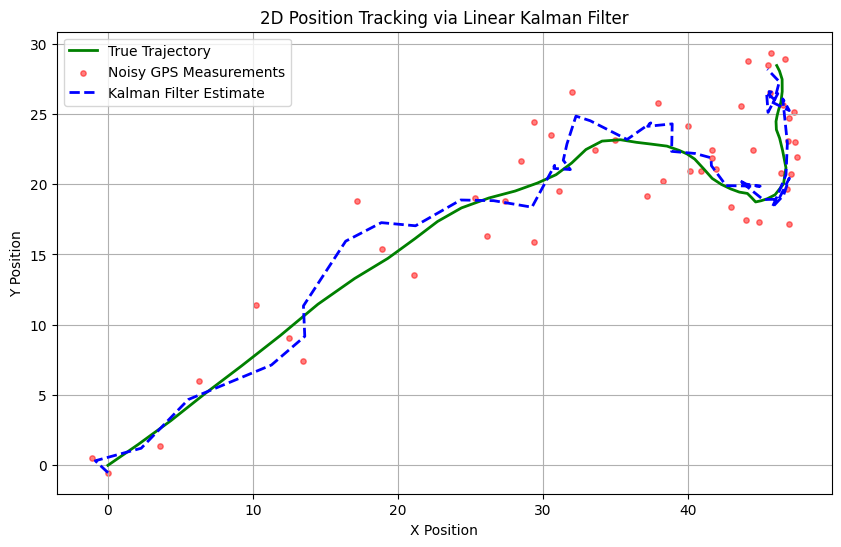

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup Simulation Parameters
dt = 1.0  # Time step
N = 50    # Number of steps

# True System Matrices
A = np.array([[1, 0, dt, 0],
              [0, 1, 0, dt],
              [0, 0, 1,  0],
              [0, 0, 0,  1]])

G = np.array([[0.5 * dt**2, 0],
              [0, 0.5 * dt**2],
              [dt, 0],
              [0, dt]])

H = np.array([[1, 0, 0, 0],
              [0, 1, 0, 0]])

# Noise Covariances
Sigma_p = np.eye(2) * 0.1  # Process noise covariance
Sigma_m = np.eye(2) * 5.0  # Measurement noise covariance (GPS error)

# Initialize Arrays
x_true = np.zeros((4, N))
y_meas = np.zeros((2, N))
x_true[:, 0] = [0, 0, 2, 1.5] # Initial position (0,0), velocity (2, 1.5)

# 2. Generate Simulated Trajectory and Noisy GPS Data
np.random.seed(42)
for k in range(1, N):
    w = np.random.multivariate_normal(np.zeros(2), Sigma_p)
    x_true[:, k] = A @ x_true[:, k-1] + G @ w

for k in range(N):
    z = np.random.multivariate_normal(np.zeros(2), Sigma_m)
    y_meas[:, k] = H @ x_true[:, k] + z

# 3. Kalman Filter Implementation
m_estimated = np.zeros((4, N))
P = np.eye(4) * 10.0 # Initial uncertainty state

# Set initial belief equal to first measurement
m_estimated[:, 0] = [y_meas[0, 0], y_meas[1, 0], 0, 0]

for k in range(1, N):
    # --- Prediction Step ---
    m_minus = A @ m_estimated[:, k-1]
    P_minus = A @ P @ A.T + G @ Sigma_p @ G.T

    # --- Update Step ---
    S = H @ P_minus @ H.T + Sigma_m
    K = P_minus @ H.T @ np.linalg.inv(S)

    y_obs = y_meas[:, k]
    m_estimated[:, k] = m_minus + K @ (y_obs - H @ m_minus)
    P = (np.eye(4) - K @ H) @ P_minus

# 4. Plot Results
plt.figure(figsize=(10, 6))
plt.plot(x_true[0, :], x_true[1, :], 'g-', label='True Trajectory', linewidth=2)
plt.scatter(y_meas[0, :], y_meas[1, :], color='red', alpha=0.5, s=15, label='Noisy GPS Measurements')
plt.plot(m_estimated[0, :], m_estimated[1, :], 'b--', label='Kalman Filter Estimate', linewidth=2)
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.title('2D Position Tracking via Linear Kalman Filter')
plt.legend()
plt.grid(True)
plt.show()